# BTRL Value Network Hyperparameter Search

Multi-objective Optuna (NSGA-II) search over the value network parameters for BTRL on DeepSea 5×5 deterministic.

**Parameters tuned:**
| Parameter | Choices | Description |
|---|---|---|
| `training_iterations` | [5, 10, 20, 50] | Gradient steps per policy update call (κ) |
| `hidden_layers` | [1, 2, 3, 4] | Number of hidden layers in the MLP |
| `hidden_dim` | [8, 16, 32, 64, 128, 256] | Width of each hidden layer |
| `learning_rate` | [1e-4, 1e-3, 1e-2] | Adam learning rate |
| `target_update_freq` | [5, 10, 20, 50] | Steps between target network copies |
| `discount` | [0.7, 0.8, 0.9, 0.95, 0.99] | Discount factor γ |

**Two objectives (minimise both):**
- **Obj 1 — `final_loss`**: MSE between value predictions and Q-targets on held-out transitions.
- **Obj 2 — `convergence_steps`**: Earliest epoch where loss drops below `TARGET_LOSS`. Falls back to `MAX_EPOCHS`.

Inputs to the value network are observed `next_states` (25-dim one-hot for env=5) — the same representation the Transformer model outputs during rollout.

In [1]:
import os, sys, json, warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import optuna
from optuna.samplers import NSGAIISampler
import yaml
from bsuite.environments.deep_sea import DeepSea

sys.path.insert(0, '.')
from TRL.common.settings import TP_THRESHOLD

from notebook_utils import (
    generate_transition_data,
    test_model_locked,
    test_model_unlocked,
    early_stopping_train,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
compute_on = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE = torch.device(compute_on)
print('Device:', DEVICE)

Device: cpu


In [2]:
CONFIG_PATH = 'configs/config_vector-setting1.yaml'
with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

config['experiment']['env'] = '5'
print('env:', config['experiment']['env'])
print('value config:', config['value'])

env: 5
value config: {'training_iterations': 10, 'hidden_layers': 1, 'hidden_dim': 256, 'learning_rate': '1e-2', 'target_update_freq': 50, 'discount': 0.95}


## Constants

In [3]:
ENV_SIZE   = int(config['experiment']['env'])  # 5
OBS_SPACE  = ENV_SIZE ** 2                     # 25
N_ACTIONS  = 2

TRAINING_ITER_CHOICES  = [5, 10, 20, 50]
HIDDEN_LAYERS_CHOICES  = [1, 2, 3, 4]
HIDDEN_DIM_CHOICES     = [8, 16, 32, 64, 128, 256]
LR_CHOICES             = [1e-4, 1e-3, 1e-2]
TARGET_UPDATE_CHOICES  = [5, 10, 20, 50]
DISCOUNT_CHOICES       = [0.7, 0.8, 0.9, 0.95, 0.99]

N_TRANSITIONS  = 1000   # data collection budget
MAX_EPOCHS     = 200    # gradient steps per trial
TARGET_LOSS    = 0.001   # convergence threshold for Obj 2
N_TRIALS       = 100
PATIENCE       = 20     # early stopping

np.random.seed(42)
torch.manual_seed(42)

## Data Collection

Collect transitions from DeepSea 5×5 using a random policy. Each transition stores the context trajectory (length `context_length`) fed to the Transformer, plus the immediate next state and reward.

In [4]:
CTX_LEN = config['transition']['context_length']
print('Collecting transitions...')
episodes, *_ = generate_transition_data(ENV_SIZE, CTX_LEN, N_TRANSITIONS)

next_states = torch.tensor(episodes['next_states'], dtype=torch.float32)
rewards     = torch.tensor(episodes['rewards'],     dtype=torch.float32).unsqueeze(1)
terminals   = torch.tensor(episodes['terminals'],   dtype=torch.float32).unsqueeze(1)
actions     = torch.tensor(episodes['actions'],     dtype=torch.long).unsqueeze(1)

# 80/20 train/test split
n      = len(next_states)
n_test = max(1, n // 5)
idx    = torch.randperm(n)
train_idx, test_idx = idx[n_test:], idx[:n_test]

tr_ns  = next_states[train_idx];  te_ns  = next_states[test_idx]
tr_r   = rewards[train_idx];      te_r   = rewards[test_idx]
tr_t   = terminals[train_idx];    te_t   = terminals[test_idx]

print(f'Train transitions: {len(train_idx)}, Test transitions: {len(test_idx)}')
print(f'next_states shape: {next_states.shape}  (obs_space={OBS_SPACE})')

_deterministic: True
Train transitions: 800, Test transitions: 200
next_states shape: torch.Size([1000, 25])  (obs_space=25)


## Value Network

Flexible version of `TRL/networks/value.py` that respects the `hidden_layers` parameter.

In [5]:
class ValueNetwork(nn.Module):
    """MLP value network with configurable depth. Matches TRL/networks/value.py interface."""
    def __init__(self, input_dim: int, hidden_dim: int, hidden_layers: int,
                 learning_rate: float, device):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.layers = nn.Sequential(*layers)
        self.loss_function = nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)
        self.to(device)

    def forward(self, x):
        return self.layers(x)

    def predict(self, x):
        with torch.no_grad():
            return self.layers(x)


def count_params(net):
    return sum(p.numel() for p in net.parameters() if p.requires_grad)

## Training and Evaluation Functions

In [6]:
def compute_targets(target_net, rewards, next_states, terminals, discount):
    """Q-learning target: r + γ · V(s') · (1 - terminal)."""
    with torch.no_grad():
        next_values = target_net(next_states).detach().flatten()
    target_values = rewards.squeeze(1) + discount * next_values * (terminals.squeeze(1) < TP_THRESHOLD)
    return target_values.unsqueeze(1)


def train_value_net(hidden_dim, hidden_layers, lr, discount,
                    target_update_freq, max_epochs, patience=PATIENCE):
    net = ValueNetwork(OBS_SPACE, hidden_dim, hidden_layers, lr, DEVICE)
    target_net = deepcopy(net.layers)
    losses, best, pat, conv_step = [], float('inf'), 0, max_epochs

    for epoch in range(max_epochs):
        if epoch % target_update_freq == 0:
            target_net = deepcopy(net.layers)

        targets = compute_targets(target_net, tr_r, tr_ns, tr_t, discount)
        net.optimizer.zero_grad()
        loss = net.loss_function(net(tr_ns), targets)
        loss.backward()
        net.optimizer.step()

        l = loss.item()
        losses.append(l)

        if l < best - 1e-6:
            best, pat = l, 0
            if l < TARGET_LOSS and conv_step == max_epochs:
                conv_step = epoch + 1
        else:
            pat += 1
            if pat >= patience:
                break

    return net, losses, conv_step


def eval_value_net(net, discount):
    """Final test loss against Q-targets on held-out transitions."""
    target_net = deepcopy(net.layers)
    targets = compute_targets(target_net, te_r, te_ns, te_t, discount)
    with torch.no_grad():
        loss = net.loss_function(net(te_ns), targets).item()
    return loss

## Optuna Objective

In [7]:
def objective(trial):
    training_iterations = trial.suggest_categorical('training_iterations', TRAINING_ITER_CHOICES)
    hidden_layers       = trial.suggest_categorical('hidden_layers',       HIDDEN_LAYERS_CHOICES)
    hidden_dim          = trial.suggest_categorical('hidden_dim',          HIDDEN_DIM_CHOICES)
    lr                  = trial.suggest_categorical('learning_rate',       LR_CHOICES)
    target_update_freq  = trial.suggest_categorical('target_update_freq',  TARGET_UPDATE_CHOICES)
    discount            = trial.suggest_categorical('discount',            DISCOUNT_CHOICES)

    # Scale max_epochs proportionally to training_iterations budget
    epochs = training_iterations * (MAX_EPOCHS // max(TRAINING_ITER_CHOICES))
    net, losses, conv_step = train_value_net(
        hidden_dim, hidden_layers, lr, discount, target_update_freq, epochs
    )

    final_loss = eval_value_net(net, discount)
    trial.set_user_attr('train_losses', losses)
    trial.set_user_attr('n_params', count_params(net))

    return final_loss, float(conv_step)

In [8]:
sampler = NSGAIISampler(seed=42)
study = optuna.create_study(
    directions=['minimize', 'minimize'],
    sampler=sampler,
    study_name='btrl_value_hparam',
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'\nCompleted {len(study.trials)} trials')

  0%|          | 0/100 [00:00<?, ?it/s]


Completed 100 trials


## Results

In [9]:
def trials_to_df(study):
    rows = []
    for t in study.trials:
        if t.values is None:
            continue
        row = dict(t.params)
        row['final_loss']        = t.values[0]
        row['convergence_steps'] = t.values[1]
        row['n_params']          = t.user_attrs.get('n_params', 0)
        row['pareto']            = t in study.best_trials
        rows.append(row)
    return pd.DataFrame(rows)


df        = trials_to_df(study)
pareto_df = df[df['pareto']].sort_values('final_loss')

print(f'Total trials: {len(df)}')
print(f'Pareto-front trials: {len(pareto_df)}')
pareto_df[['training_iterations','hidden_layers','hidden_dim',
           'learning_rate','target_update_freq','discount',
           'final_loss','convergence_steps','n_params']].round(5)

Total trials: 100
Pareto-front trials: 1


,training_iterations,hidden_layers,hidden_dim,learning_rate,target_update_freq,discount,final_loss,convergence_steps,n_params
97,5,1,32,0.0001,20,0.95,0.01809,20.0,865


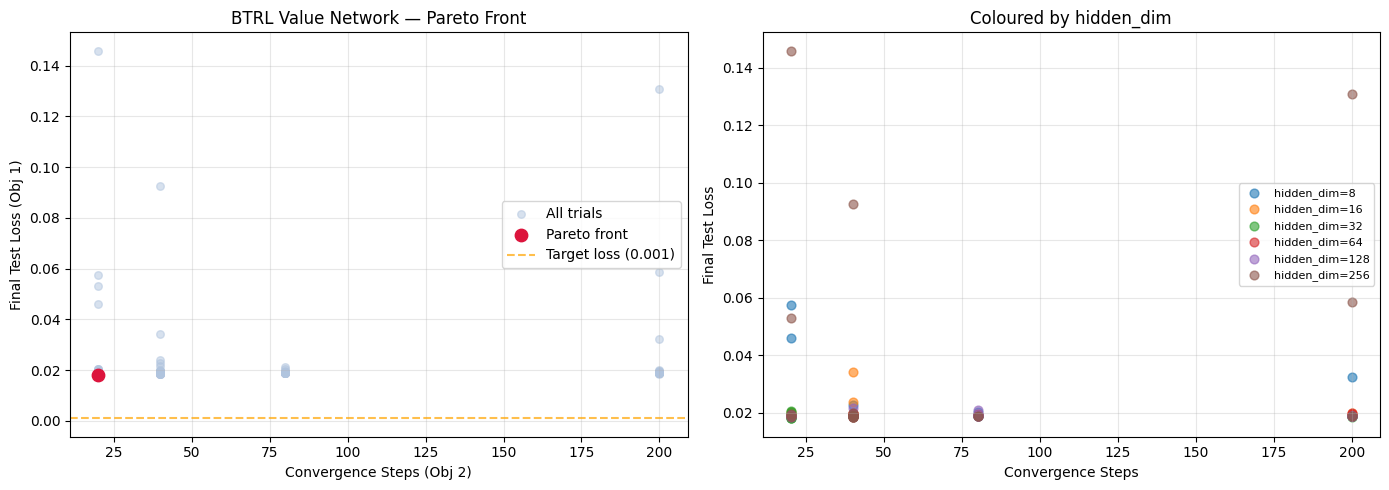

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(df['convergence_steps'], df['final_loss'],
           c='lightsteelblue', alpha=0.5, s=30, label='All trials')
ax.scatter(pareto_df['convergence_steps'], pareto_df['final_loss'],
           c='crimson', s=80, zorder=5, label='Pareto front')
ax.axhline(TARGET_LOSS, color='orange', linestyle='--', alpha=0.7,
           label=f'Target loss ({TARGET_LOSS})')
ax.set_xlabel('Convergence Steps (Obj 2)')
ax.set_ylabel('Final Test Loss (Obj 1)')
ax.set_title('BTRL Value Network — Pareto Front')
ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
for hd in sorted(df['hidden_dim'].unique()):
    sub = df[df['hidden_dim'] == hd]
    ax2.scatter(sub['convergence_steps'], sub['final_loss'],
                alpha=0.6, s=40, label=f'hidden_dim={hd}')
ax2.set_xlabel('Convergence Steps')
ax2.set_ylabel('Final Test Loss')
ax2.set_title('Coloured by hidden_dim')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

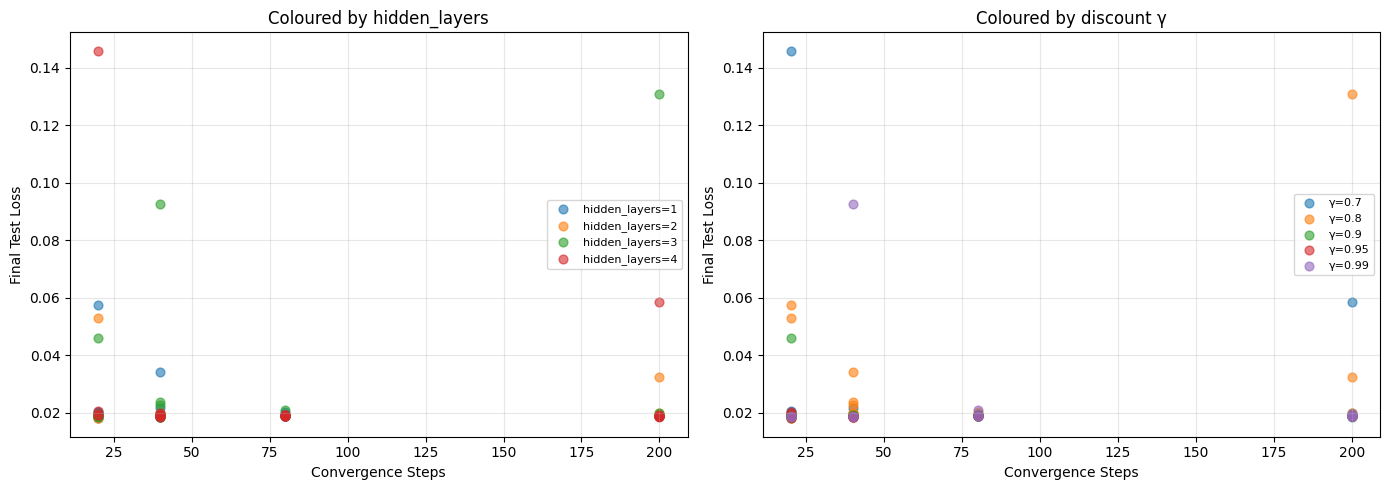

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for hl in sorted(df['hidden_layers'].unique()):
    sub = df[df['hidden_layers'] == hl]
    ax.scatter(sub['convergence_steps'], sub['final_loss'],
               alpha=0.6, s=40, label=f'hidden_layers={hl}')
ax.set_xlabel('Convergence Steps'); ax.set_ylabel('Final Test Loss')
ax.set_title('Coloured by hidden_layers'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax2 = axes[1]
for d in sorted(df['discount'].unique()):
    sub = df[df['discount'] == d]
    ax2.scatter(sub['convergence_steps'], sub['final_loss'],
                alpha=0.6, s=40, label=f'γ={d}')
ax2.set_xlabel('Convergence Steps'); ax2.set_ylabel('Final Test Loss')
ax2.set_title('Coloured by discount γ'); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Best Model — Retrain and Evaluate

In [12]:
# Pick Pareto-optimal trial with best balance (normalised sum of both objectives)
if len(pareto_df) > 0:
    pdf = pareto_df.copy()
    for col in ['final_loss', 'convergence_steps']:
        rng = pdf[col].max() - pdf[col].min()
        pdf[col + '_norm'] = (pdf[col] - pdf[col].min()) / (rng if rng > 0 else 1)
    pdf['score'] = pdf['final_loss_norm'] + pdf['convergence_steps_norm']
    best_row = pdf.loc[pdf['score'].idxmin()]
else:
    best_row = df.loc[df['final_loss'].idxmin()]

best_hidden_dim         = int(best_row['hidden_dim'])
best_hidden_layers      = int(best_row['hidden_layers'])
best_lr                 = float(best_row['learning_rate'])
best_discount           = float(best_row['discount'])
best_target_update_freq = int(best_row['target_update_freq'])
best_training_iters     = int(best_row['training_iterations'])

print('Best config:')
print(f'  training_iterations={best_training_iters}')
print(f'  hidden_layers={best_hidden_layers},  hidden_dim={best_hidden_dim}')
print(f'  learning_rate={best_lr},  target_update_freq={best_target_update_freq}')
print(f'  discount={best_discount}')
print(f'  Pareto final_loss={best_row["final_loss"]:.5f},  conv_steps={best_row["convergence_steps"]:.0f}')

# Retrain with full MAX_EPOCHS to get a stable evaluation
best_net, best_losses, best_conv = train_value_net(
    best_hidden_dim, best_hidden_layers, best_lr, best_discount,
    best_target_update_freq, max_epochs=MAX_EPOCHS
)
final_test_loss = eval_value_net(best_net, best_discount)
n_params = count_params(best_net)

print(f'\nRetrained → test_loss={final_test_loss:.5f},  convergence_step={best_conv}')
print(f'Parameters: {n_params:,}')

Best config:
  training_iterations=5
  hidden_layers=1,  hidden_dim=32
  learning_rate=0.0001,  target_update_freq=20
  discount=0.95
  Pareto final_loss=0.01809,  conv_steps=20

Retrained → test_loss=0.01909,  convergence_step=200
Parameters: 865


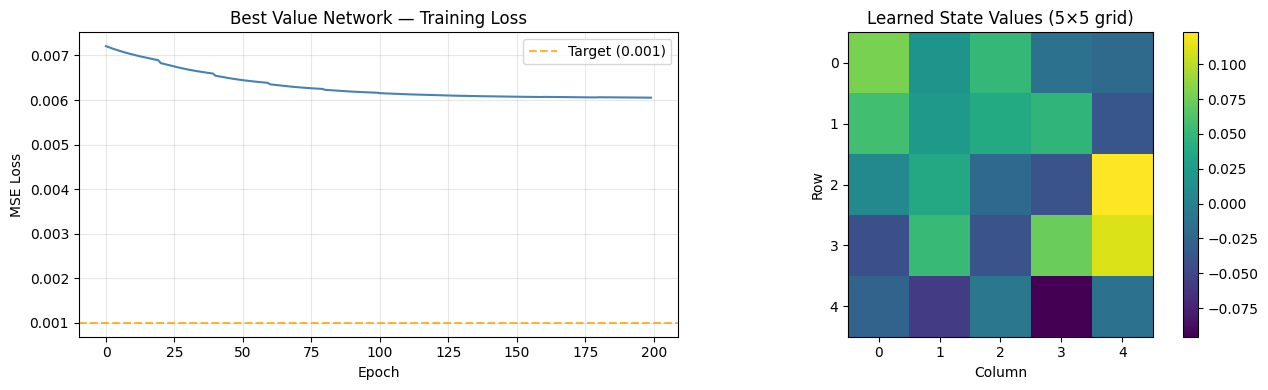

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(best_losses, color='steelblue', linewidth=1.5)
ax.axhline(TARGET_LOSS, color='orange', linestyle='--', alpha=0.8, label=f'Target ({TARGET_LOSS})')
if best_conv < MAX_EPOCHS:
    ax.axvline(best_conv, color='crimson', linestyle=':', alpha=0.8,
               label=f'Converged @ step {best_conv}')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Best Value Network — Training Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# Value map over the 5×5 grid
ax2 = axes[1]
values = np.zeros((ENV_SIZE, ENV_SIZE))
best_net.eval()
with torch.no_grad():
    for i in range(ENV_SIZE):
        for j in range(ENV_SIZE):
            s = torch.zeros(1, OBS_SPACE)
            s[0, i * ENV_SIZE + j] = 1.0
            values[i, j] = best_net(s).item()
best_net.train()
im = ax2.imshow(values, cmap='viridis')
plt.colorbar(im, ax=ax2)
ax2.set_title('Learned State Values (5×5 grid)')
ax2.set_xlabel('Column'); ax2.set_ylabel('Row')

plt.tight_layout()
plt.show()

## Save Optimal Parameters

In [14]:
optimal_params = {
    'training_iterations': best_training_iters,
    'hidden_layers':       best_hidden_layers,
    'hidden_dim':          best_hidden_dim,
    'learning_rate':       best_lr,
    'target_update_freq':  best_target_update_freq,
    'discount':            best_discount,
    'final_test_loss':     float(final_test_loss),
    'convergence_steps':   int(best_conv),
    'n_parameters':        n_params,
    'env_size':            ENV_SIZE,
    'obs_space':           OBS_SPACE,
    'n_trials':            N_TRIALS,
    'data_samples':        N_TRANSITIONS,
}

out_path = Path('configs/btrl_value_params.json')
out_path.parent.mkdir(exist_ok=True)
with open(out_path, 'w') as f:
    json.dump(optimal_params, f, indent=2)
print(f'Saved to {out_path}')
print(json.dumps(optimal_params, indent=2))

Saved to configs/btrl_value_params.json
{
  "training_iterations": 5,
  "hidden_layers": 1,
  "hidden_dim": 32,
  "learning_rate": 0.0001,
  "target_update_freq": 20,
  "discount": 0.95,
  "final_test_loss": 0.01909402757883072,
  "convergence_steps": 200,
  "n_parameters": 865,
  "env_size": 5,
  "obs_space": 25,
  "n_trials": 100,
  "data_samples": 1000
}
